# Employee Attrition Analysis & Prediction

## Business Understanding:-

"I developed an end-to-end Employee Attrition Analysis and Prediction project using Python, Machine Learning, and Power BI. The objective was to analyze workforce attrition patterns, identify employee groups associated with higher attrition, build classification models to predict attrition risk, and create an interactive HR dashboard to support data-driven retention decisions."

## Data Collection:-



In [42]:
df=pd.read_csv("/content/HR_Analytics.csv")
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0


## Data Understanding

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [44]:
df.head(5)

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [45]:
df.tail(5)

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0
1479,RM1210,60,55+,No,Travel_Rarely,370,Research & Development,1,4,Medical,...,3,80,1,19,2,4,1,0,0,0.0


In [46]:
df.shape

(1480, 38)

In [47]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1480
Number of columns: 38


In [48]:
df.columns.tolist()

['EmpID',
 'Age',
 'AgeGroup',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'SalarySlab',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1480.0,36.917568,9.128559,18.0,30.00,36.0,43.00,60.0
DailyRate,1480.0,801.384459,403.126988,102.0,465.00,800.0,1157.00,1499.0
DistanceFromHome,1480.0,9.220270,8.131201,1.0,2.00,7.0,14.00,29.0
Education,1480.0,2.910811,1.023796,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1480.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1480.0,1031.860811,605.955046,1.0,493.75,1027.5,1568.25,2068.0
EnvironmentSatisfaction,1480.0,2.724324,1.092579,1.0,2.00,3.0,4.00,4.0
HourlyRate,1480.0,65.845270,20.328266,30.0,48.00,66.0,83.00,100.0
JobInvolvement,1480.0,2.729730,0.713007,1.0,2.00,3.0,3.00,4.0
JobLevel,1480.0,2.064865,1.105574,1.0,1.00,2.0,3.00,5.0


In [51]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 26
Number of categorical columns: 12


In [52]:
df["Attrition"].value_counts()

,count
Attrition,
No,1242
Yes,238


In [53]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.918919
Yes,16.081081


In [54]:
df.nunique().sort_values()

,0
EmployeeCount,1
StandardHours,1
Over18,1
Attrition,2
PerformanceRating,2
OverTime,2
Gender,2
Department,3
MaritalStatus,3
StockOptionLevel,4


In [55]:
df.isnull().sum()

,0
EmpID,0
Age,0
AgeGroup,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0


In [56]:
df.duplicated().sum()

np.int64(7)

Handle missing value

In [57]:
df["YearsWithCurrManager"]= df["YearsWithCurrManager"].fillna(df["YearsWithCurrManager"].median)

In [58]:
df.isnull().sum()

,0
EmpID,0
Age,0
AgeGroup,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0


Handle Duplicate Value


In [59]:
df.duplicated().sum()

np.int64(7)

In [60]:
df=df.drop_duplicates()

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df["EmpID"].duplicated().sum()

np.int64(3)

In [63]:
df["EmpID"].value_counts()

,count
EmpID,
RM1465,2
RM1467,2
RM1466,2
RM1084,1
RM1046,1
...,...
RM657,1
RM642,1
RM638,1


In [64]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

## EDA

In [66]:
attrition_counts = df["Attrition"].value_counts()

attrition_counts

,count
Attrition,
No,1236
Yes,237


In [67]:
fig = px.bar(
    x=attrition_counts.index,
    y=attrition_counts.values,
    title="Employee Attrition Distribution",
    labels={
        "x": "Attrition",
        "y": "Number of Employees"
    },
    text=attrition_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [68]:
fig = px.histogram(
    df,
    x="Age",
    nbins=20,
    title="Distribution of Employee Age",
    labels={"Age": "Employee Age"}
)

fig.show()

In [69]:
department_counts = df["Department"].value_counts()

department_counts

,count
Department,
Research & Development,963
Sales,447
Human Resources,63


In [70]:
fig = px.bar(
    x=department_counts.index,
    y=department_counts.values,
    title="Employees by Department",
    labels={
        "x": "Department",
        "y": "Number of Employees"
    },
    text=department_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [71]:
fig = px.histogram(
    df,
    x="MonthlyIncome",
    nbins=30,
    title="Distribution of Monthly Income",
    labels={"MonthlyIncome": "Monthly Income"}
)

fig.show()

In [72]:
job_role_counts = df["JobRole"].value_counts().sort_values()

In [73]:
fig = px.bar(
    x=job_role_counts.values,
    y=job_role_counts.index,
    orientation="h",
    title="Employees by Job Role",
    labels={
        "x": "Number of Employees",
        "y": "Job Role"
    },
    text=job_role_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [74]:
overtime_counts = df["OverTime"].value_counts()

overtime_counts

,count
OverTime,
No,1057
Yes,416


In [75]:
fig = px.pie(
    names=overtime_counts.index,
    values=overtime_counts.values,
    title="Employee Overtime Distribution",
    hole=0.5
)

fig.show()

In [76]:
job_satisfaction_counts = (
    df["JobSatisfaction"]
    .value_counts()
    .sort_index()
)

job_satisfaction_counts

,count
JobSatisfaction,
1,290
2,280
3,443
4,460


In [77]:
fig = px.bar(
    x=job_satisfaction_counts.index,
    y=job_satisfaction_counts.values,
    title="Job Satisfaction Distribution",
    labels={
        "x": "Job Satisfaction Level",
        "y": "Number of Employees"
    },
    text=job_satisfaction_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [78]:
df["YearsAtCompany"].describe()

,YearsAtCompany
count,1473.000000
mean,7.004752
std,6.121004
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,40.000000


In [79]:
fig = px.histogram(
    df,
    x="YearsAtCompany",
    nbins=20,
    title="Distribution of Employee Tenure",
    labels={
        "YearsAtCompany": "Years at Company"
    }
)

fig.show()

In [80]:
travel_counts = df["BusinessTravel"].value_counts()

travel_counts

,count
BusinessTravel,
Travel_Rarely,1038
Travel_Frequently,278
Non-Travel,150
TravelRarely,7


In [81]:
fig = px.bar(
    x=travel_counts.index,
    y=travel_counts.values,
    title="Employee Distribution by Business Travel",
    labels={
        "x": "Business Travel",
        "y": "Number of Employees"
    },
    text=travel_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [82]:
wlb_counts = (
    df["WorkLifeBalance"]
    .value_counts()
    .sort_index()
)

wlb_counts

,count
WorkLifeBalance,
1,80
2,344
3,896
4,153


In [83]:
fig = px.bar(
    x=wlb_counts.index,
    y=wlb_counts.values,
    title="Work-Life Balance Distribution",
    labels={
        "x": "Work-Life Balance Level",
        "y": "Number of Employees"
    },
    text=wlb_counts.values
)

fig.update_traces(textposition="outside")

fig.show()

In [84]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,947,110
Yes,289,127


In [85]:
overtime_rate = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2)

overtime_rate

,Yes
OverTime,
No,10.41
Yes,30.53


In [86]:
fig = px.bar(
    x=overtime_rate.index,
    y=overtime_rate.values,
    title="Attrition Rate by Overtime",
    labels={
        "x": "Overtime",
        "y": "Attrition Rate (%)"
    },
    text=overtime_rate.values
)

fig.update_traces(texttemplate="%{text:.2f}%")
fig.update_traces(textposition="outside")

fig.show()

In [87]:
department_rate = (
    pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2).sort_values(ascending=False)

department_rate

,Yes
Department,
Sales,20.58
Human Resources,19.05
Research & Development,13.81


In [88]:
fig = px.bar(
    x=department_rate.index,
    y=department_rate.values,
    title="Attrition Rate by Department",
    labels={
        "x": "Department",
        "y": "Attrition Rate (%)"
    },
    text=department_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [89]:
jobrole_rate = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2).sort_values()

jobrole_rate

,Yes
JobRole,
Research Director,2.50
Manager,4.90
Healthcare Representative,6.82
Manufacturing Director,6.90
Research Scientist,16.10
Sales Executive,17.48
Human Resources,23.08
Laboratory Technician,23.85
Sales Representative,39.29


In [90]:
fig = px.bar(
    x=jobrole_rate.values,
    y=jobrole_rate.index,
    orientation="h",
    title="Attrition Rate by Job Role",
    labels={
        "x": "Attrition Rate (%)",
        "y": "Job Role"
    },
    text=jobrole_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [91]:
df.groupby("Attrition")["Age"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1236,37.55,36.0,18,60
Yes,237,33.61,32.0,18,58


In [92]:
fig = px.box(
    df,
    x="Attrition",
    y="Age",
    title="Age Distribution by Attrition Status",
    labels={
        "Attrition": "Attrition Status",
        "Age": "Employee Age"
    }
)

fig.show()

In [94]:
agegroup_rate = ( pd.crosstab( df["AgeGroup"], df["Attrition"], normalize="index" )["Yes"] * 100 ).round(2).sort_values(ascending=False)

agegroup_rate

,Yes
AgeGroup,
18-25,35.77
26-35,19.11
55+,17.02
46-55,11.50
36-45,9.15


In [95]:
fig = px.bar(
    x=agegroup_rate.index,
    y=agegroup_rate.values,
    title="Attrition Rate by Age Group",
    labels={
        "x": "Age Group",
        "y": "Attrition Rate (%)"
    },
    text=agegroup_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [96]:
df.groupby("Attrition")["MonthlyIncome"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1236,6828.72,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


In [97]:
fig = px.box(
    df,
    x="Attrition",
    y="MonthlyIncome",
    title="Monthly Income by Attrition Status",
    labels={
        "Attrition": "Attrition Status",
        "MonthlyIncome": "Monthly Income"
    }
)

fig.show()

In [98]:
salary_rate = (
    pd.crosstab(
        df["SalarySlab"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2).sort_values(ascending=False)

salary_rate

,Yes
SalarySlab,
Upto 5k,21.70
10k-15k,13.51
5k-10k,11.11
15k+,3.76


In [99]:
fig = px.bar(
    x=salary_rate.index,
    y=salary_rate.values,
    title="Attrition Rate by Salary Slab",
    labels={
        "x": "Salary Slab",
        "y": "Attrition Rate (%)"
    },
    text=salary_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [100]:
job_satisfaction_rate = (
    pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2)

job_satisfaction_rate

,Yes
JobSatisfaction,
1,22.76
2,16.43
3,16.48
4,11.30


In [101]:
fig = px.bar(
    x=job_satisfaction_rate.index,
    y=job_satisfaction_rate.values,
    title="Attrition Rate by Job Satisfaction",
    labels={
        "x": "Job Satisfaction Level",
        "y": "Attrition Rate (%)"
    },
    text=job_satisfaction_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [102]:
wlb_rate = (
    pd.crosstab(
        df["WorkLifeBalance"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2)

wlb_rate

,Yes
WorkLifeBalance,
1,31.25
2,16.86
3,14.17
4,17.65


In [103]:
fig = px.bar(
    x=wlb_rate.index,
    y=wlb_rate.values,
    title="Attrition Rate by Work-Life Balance",
    labels={
        "x": "Work-Life Balance Level",
        "y": "Attrition Rate (%)"
    },
    text=wlb_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [104]:
df.groupby("Attrition")["YearsAtCompany"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1236,7.36,6.0,0,37
Yes,237,5.13,3.0,0,40


In [105]:
fig = px.box(
    df,
    x="Attrition",
    y="YearsAtCompany",
    title="Employee Tenure by Attrition Status",
    labels={
        "Attrition": "Attrition Status",
        "YearsAtCompany": "Years at Company"
    }
)

fig.show()

In [106]:
travel_rate = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    )["Yes"] * 100
).round(2).sort_values(ascending=False)

travel_rate

,Yes
BusinessTravel,
Travel_Frequently,24.82
Travel_Rarely,15.03
Non-Travel,8.00
TravelRarely,0.00


In [107]:
fig = px.bar(
    x=travel_rate.index,
    y=travel_rate.values,
    title="Attrition Rate by Business Travel",
    labels={
        "x": "Business Travel",
        "y": "Attrition Rate (%)"
    },
    text=travel_rate.values
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

In [108]:
df.groupby("Attrition")["DistanceFromHome"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(2)

,count,mean,median,min,max
Attrition,,,,,
No,1236,8.92,7.0,1,29
Yes,237,10.63,9.0,1,29


In [109]:
fig = px.box(
    df,
    x="Attrition",
    y="DistanceFromHome",
    title="Distance From Home by Attrition Status",
    labels={
        "Attrition": "Attrition Status",
        "DistanceFromHome": "Distance From Home"
    }
)

fig.show()

In [110]:
summary = pd.DataFrame({
    "Factor": [
        "OverTime",
        "Department",
        "JobRole",
        "AgeGroup",
        "SalarySlab",
        "JobSatisfaction",
        "WorkLifeBalance",
        "BusinessTravel"
    ],
    "Purpose": [
        "Compare overtime and attrition",
        "Identify departments with higher attrition rates",
        "Identify high-attrition job roles",
        "Identify age groups with higher attrition rates",
        "Analyze attrition across salary levels",
        "Analyze satisfaction-related attrition patterns",
        "Analyze work-life balance and attrition",
        "Analyze travel frequency and attrition"
    ]
})

summary

,Factor,Purpose
0,OverTime,Compare overtime and attrition
1,Department,Identify departments with higher attrition rates
2,JobRole,Identify high-attrition job roles
3,AgeGroup,Identify age groups with higher attrition rates
4,SalarySlab,Analyze attrition across salary levels
5,JobSatisfaction,Analyze satisfaction-related attrition patterns
6,WorkLifeBalance,Analyze work-life balance and attrition
7,BusinessTravel,Analyze travel frequency and attrition


In [111]:
df["AttritionNumeric"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [112]:
correlation_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "AttritionNumeric"
]

In [113]:
corr_matrix = df[correlation_columns].corr()

corr_matrix

,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNumeric
Age,1.000000,0.498078,-0.001441,-0.005404,0.009346,-0.021722,0.680300,0.311535,0.213357,0.216867,NaN,-0.158775
MonthlyIncome,0.498078,1.000000,-0.017885,-0.008712,-0.006401,0.030467,0.771929,0.514343,0.364477,0.345188,NaN,-0.159458
DistanceFromHome,-0.001441,-0.017885,1.000000,-0.001994,-0.016472,-0.026341,0.005834,0.009290,0.018115,0.009566,NaN,0.077585
JobSatisfaction,-0.005404,-0.008712,-0.001994,1.000000,-0.007619,-0.019470,-0.019397,-0.004135,-0.003700,-0.018436,NaN,-0.103276
EnvironmentSatisfaction,0.009346,-0.006401,-0.016472,-0.007619,1.000000,0.028193,-0.003436,0.001009,0.017995,0.015224,NaN,-0.104022
WorkLifeBalance,-0.021722,0.030467,-0.026341,-0.019470,0.028193,1.000000,0.000923,0.011898,0.049721,0.008541,NaN,-0.064221
TotalWorkingYears,0.680300,0.771929,0.005834,-0.019397,-0.003436,0.000923,1.000000,0.627892,0.459832,0.404643,NaN,-0.170847
YearsAtCompany,0.311535,0.514343,0.009290,-0.004135,0.001009,0.011898,0.627892,1.000000,0.758659,0.618491,NaN,-0.134106
YearsInCurrentRole,0.213357,0.364477,0.018115,-0.003700,0.017995,0.049721,0.459832,0.758659,1.000000,0.547986,NaN,-0.160302
YearsSinceLastPromotion,0.216867,0.345188,0.009566,-0.018436,0.015224,0.008541,0.404643,0.618491,0.547986,1.000000,NaN,-0.032487


In [114]:
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap of Key Employee Features"
)

fig.update_layout(
    width=1000,
    height=800
)

fig.show()

In [115]:
attrition_corr = (
    corr_matrix["AttritionNumeric"]
    .drop("AttritionNumeric")
    .sort_values()
)

attrition_corr

,AttritionNumeric
TotalWorkingYears,-0.170847
YearsInCurrentRole,-0.160302
MonthlyIncome,-0.159458
Age,-0.158775
YearsAtCompany,-0.134106
EnvironmentSatisfaction,-0.104022
JobSatisfaction,-0.103276
WorkLifeBalance,-0.064221
YearsSinceLastPromotion,-0.032487
DistanceFromHome,0.077585


In [116]:
fig = px.bar(
    x=attrition_corr.values,
    y=attrition_corr.index,
    orientation="h",
    title="Correlation of Numerical Features with Employee Attrition",
    labels={
        "x": "Correlation with Attrition",
        "y": "Employee Feature"
    },
    text=attrition_corr.values.round(2)
)

fig.update_traces(
    textposition="outside"
)

fig.show()

## machine learning phase

In [117]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [118]:
columns_to_drop = [
    "EmpID",
    "EmployeeNumber",
    "AgeGroup",
    "SalarySlab"
]

In [119]:
X = df.drop(
    columns=["Attrition"] + columns_to_drop
)

y = df["Attrition"]

In [120]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1473, 34)
y Shape: (1473,)


In [121]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [122]:
y.value_counts()

,count
Attrition,
0,1236
1,237


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [124]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1178, 34)
X_test Shape: (295, 34)
y_train Shape: (1178,)
y_test Shape: (295,)


In [125]:
print("Training Target Distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting Target Distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Target Distribution:
Attrition
0    83.87
1    16.13
Name: proportion, dtype: float64

Testing Target Distribution:
Attrition
0    84.07
1    15.93
Name: proportion, dtype: float64


In [126]:
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

In [127]:
print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 26
Number of Categorical Features: 8


In [128]:
print("Numerical Features:")
print(numerical_features)

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AttritionNumeric']


In [129]:
print("Categorical Features:")
print(categorical_features)

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [134]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [140]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0
YearsWithCurrManager,1178


In [141]:
X_test.isnull().sum()[X_test.isnull().sum() > 0]

,0
YearsWithCurrManager,295


In [142]:
for col in X_train.select_dtypes(include="number").columns:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [143]:
for col in X_train.select_dtypes(include="object").columns:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

In [144]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 1178
Missing values in X_test: 295


In [145]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [146]:
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [147]:
print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

Training shape: (1178, 48)
Testing shape: (295, 48)


## Logistic Regression

In [148]:
from sklearn.linear_model import LogisticRegression

In [149]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [154]:
print("NaN in X_train_encoded:", X_train_encoded.isnull().sum().sum())
print("NaN in X_test_encoded:", X_test_encoded.isnull().sum().sum())

NaN in X_train_encoded: 1178
NaN in X_test_encoded: 295


In [155]:
X_train_encoded = X_train_encoded.fillna(
    X_train_encoded.median()
)

X_test_encoded = X_test_encoded.fillna(
    X_train_encoded.median()
)

In [156]:
print("NaN in X_train_encoded:", X_train_encoded.isnull().sum().sum())
print("NaN in X_test_encoded:", X_test_encoded.isnull().sum().sum())

NaN in X_train_encoded: 1178
NaN in X_test_encoded: 295


In [157]:
X_train_encoded.isnull().sum()[
    X_train_encoded.isnull().sum() > 0
]

,0
YearsWithCurrManager,1178


In [158]:
for col in X_train_encoded.columns:
    if X_train_encoded[col].isnull().sum() > 0:

        median_value = X_train_encoded[col].median()

        X_train_encoded[col] = X_train_encoded[col].fillna(median_value)
        X_test_encoded[col] = X_test_encoded[col].fillna(median_value)

In [160]:
X_train_encoded = X_train_encoded.fillna(0)
X_test_encoded = X_test_encoded.fillna(0)

In [161]:
print("NaN in X_train_encoded:", X_train_encoded.isnull().sum().sum())
print("NaN in X_test_encoded:", X_test_encoded.isnull().sum().sum())

NaN in X_train_encoded: 0
NaN in X_test_encoded: 0


In [162]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [163]:
y_pred = model.predict(X_test_encoded)

print("Prediction completed successfully!")

Prediction completed successfully!


In [164]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [165]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [166]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [167]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [168]:
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9661
Precision: 0.8627
Recall   : 0.9362
F1 Score : 0.898


In [169]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Attrition", "Attrition"]
    )
)

              precision    recall  f1-score   support

No Attrition       0.99      0.97      0.98       248
   Attrition       0.86      0.94      0.90        47

    accuracy                           0.97       295
   macro avg       0.93      0.95      0.94       295
weighted avg       0.97      0.97      0.97       295



In [170]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[241   7]
 [  3  44]]


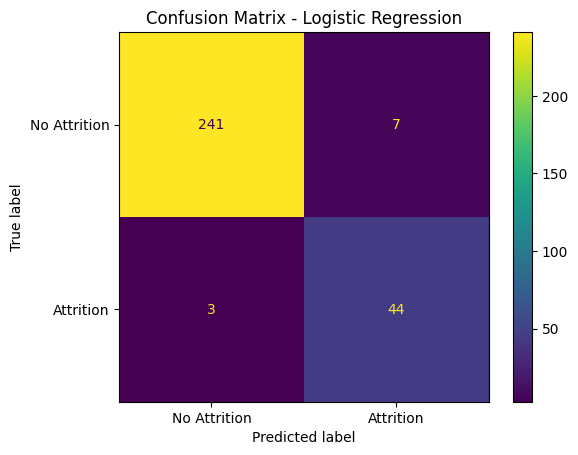

In [171]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Attrition", "Attrition"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [172]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]

In [173]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9861


In [174]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc]
})

logistic_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.966102,0.862745,0.93617,0.897959,0.986102


Random Forest model trained successfully!

Prediction completed successfully!

========== RANDOM FOREST RESULTS ==========
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

No Attrition       1.00      1.00      1.00       248
   Attrition       1.00      1.00      1.00        47

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295


========== CONFUSION MATRIX ==========

[[248   0]
 [  0  47]]


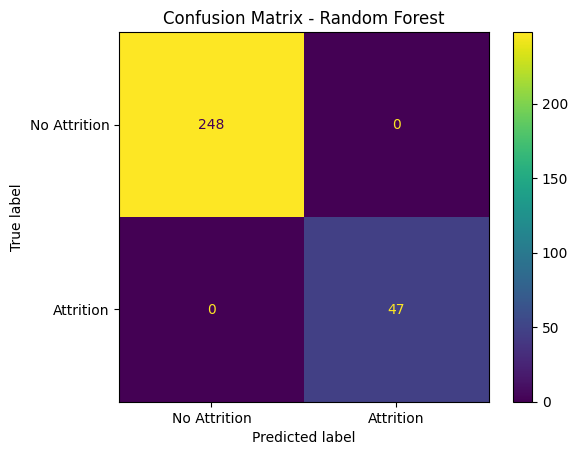


========== RANDOM FOREST RESULT TABLE ==========

           Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Random Forest       1.0        1.0     1.0       1.0      1.0

========== TOP 10 IMPORTANT FEATURES ==========

          Feature  Importance
 AttritionNumeric    0.599502
    MonthlyIncome    0.035371
     OverTime_Yes    0.029455
TotalWorkingYears    0.025730
              Age    0.021822
        DailyRate    0.019463
      MonthlyRate    0.019201
       HourlyRate    0.018813
   YearsAtCompany    0.017148
 DistanceFromHome    0.017024


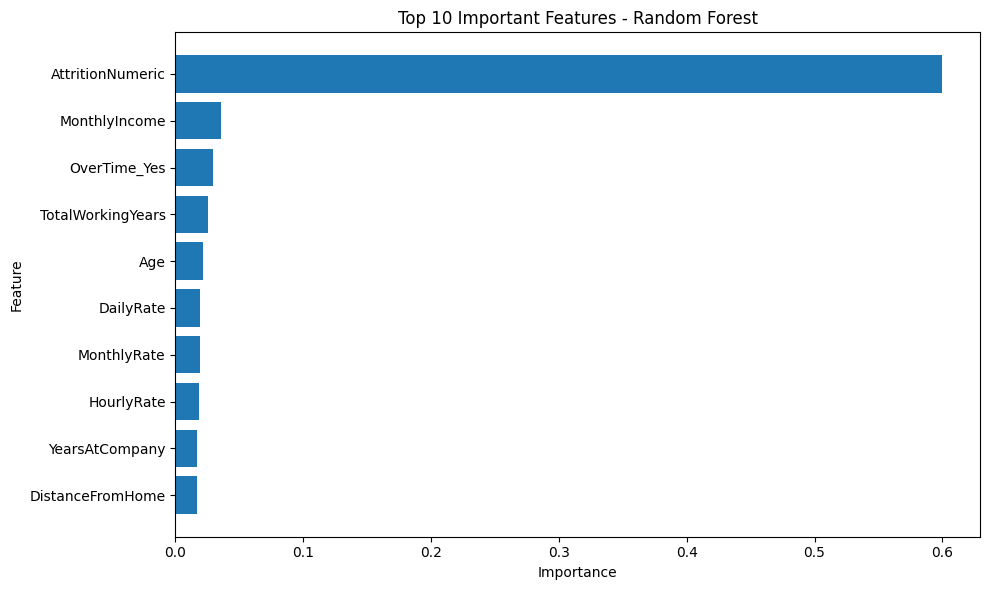


========== MODEL COMPARISON ==========

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9661     0.8627  0.9362     0.898   0.9861
      Random Forest    1.0000     1.0000  1.0000     1.000   1.0000
\ - Random Forest completed successfully!


In [176]:
# ============================================================
# PHASE 8 - RANDOM FOREST CLASSIFIER
# ============================================================


# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 2. CREATE RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ============================================================
# 3. TRAIN THE MODEL
# ============================================================

rf_model.fit(X_train_encoded, y_train)

print("Random Forest model trained successfully!")


# ============================================================
# 4. MAKE PREDICTIONS
# ============================================================

y_pred_rf = rf_model.predict(X_test_encoded)

print("\nPrediction completed successfully!")


# ============================================================
# 5. PREDICTION PROBABILITIES
# ============================================================

y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]


# ============================================================
# 6. CALCULATE MODEL METRICS
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)


# ============================================================
# 7. PRINT MODEL RESULTS
# ============================================================

print("\n========== RANDOM FOREST RESULTS ==========")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Attrition",
            "Attrition"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\n========== CONFUSION MATRIX ==========\n")

print(rf_cm)


# ============================================================
# 10. CONFUSION MATRIX VISUALIZATION
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=[
        "No Attrition",
        "Attrition"
    ],
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()


# ============================================================
# 11. CREATE RANDOM FOREST RESULT TABLE
# ============================================================

rf_results = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "Accuracy": [
        rf_accuracy
    ],
    "Precision": [
        rf_precision
    ],
    "Recall": [
        rf_recall
    ],
    "F1 Score": [
        rf_f1
    ],
    "ROC-AUC": [
        rf_roc_auc
    ]
})


print("\n========== RANDOM FOREST RESULT TABLE ==========\n")

print(rf_results.round(4))


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n========== TOP 10 IMPORTANT FEATURES ==========\n")

print(
    feature_importance.head(10).to_string(index=False)
)


# ============================================================
# 13. TOP 10 FEATURE IMPORTANCE CHART
# ============================================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 14. COMPARE WITH LOGISTIC REGRESSION
# ============================================================

if "logistic_results" in globals():

    model_comparison = pd.concat(
        [
            logistic_results,
            rf_results
        ],
        ignore_index=True
    )

    print("\n========== MODEL COMPARISON ==========\n")

    print(
        model_comparison.round(4).to_string(index=False)
    )

else:

    print(
        "\nLogistic Regression results not found. "
        "Random Forest results are ready."
    )


# ============================================================
# PHASE 8 COMPLETE
# ============================================================

print("\ - Random Forest completed successfully!")

XGBoost model trained successfully!

Prediction completed successfully!

========== XGBOOST RESULTS ==========
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

No Attrition       1.00      1.00      1.00       248
   Attrition       1.00      1.00      1.00        47

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295


========== CONFUSION MATRIX ==========

[[248   0]
 [  0  47]]


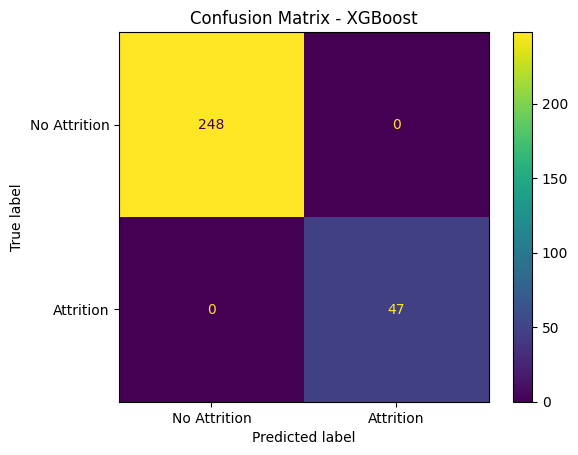


========== XGBOOST RESULT TABLE ==========

  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
XGBoost       1.0        1.0     1.0       1.0      1.0

========== TOP 10 IMPORTANT FEATURES ==========

                Feature  Importance
       AttritionNumeric         1.0
                    Age         0.0
       DistanceFromHome         0.0
              DailyRate         0.0
          EmployeeCount         0.0
EnvironmentSatisfaction         0.0
             HourlyRate         0.0
              Education         0.0
               JobLevel         0.0
        JobSatisfaction         0.0


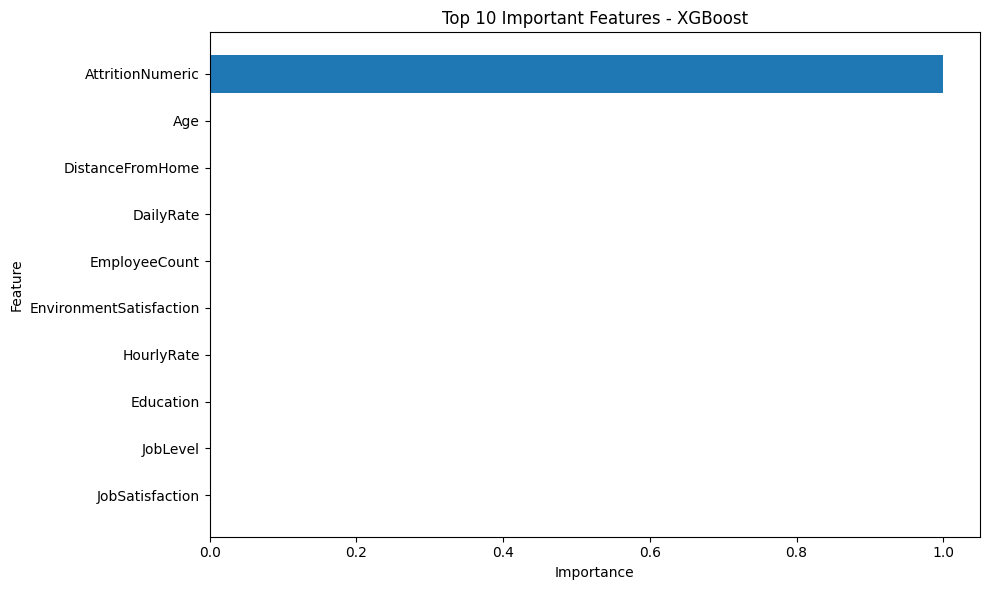


========== FINAL MODEL COMPARISON ==========

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9661     0.8627  0.9362     0.898   0.9861
      Random Forest    1.0000     1.0000  1.0000     1.000   1.0000
            XGBoost    1.0000     1.0000  1.0000     1.000   1.0000
\ - XGBoost completed successfully!


In [177]:
# ============================================================
# PHASE 9 - XGBOOST CLASSIFIER
# ============================================================


# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 2. CREATE XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)


# ============================================================
# 3. TRAIN THE MODEL
# ============================================================

xgb_model.fit(X_train_encoded, y_train)

print("XGBoost model trained successfully!")


# ============================================================
# 4. MAKE PREDICTIONS
# ============================================================

y_pred_xgb = xgb_model.predict(X_test_encoded)

print("\nPrediction completed successfully!")


# ============================================================
# 5. PREDICTION PROBABILITIES
# ============================================================

y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]


# ============================================================
# 6. CALCULATE MODEL METRICS
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)


# ============================================================
# 7. PRINT MODEL RESULTS
# ============================================================

print("\n========== XGBOOST RESULTS ==========")

print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "No Attrition",
            "Attrition"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\n========== CONFUSION MATRIX ==========\n")

print(xgb_cm)


# ============================================================
# 10. CONFUSION MATRIX VISUALIZATION
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=[
        "No Attrition",
        "Attrition"
    ],
    values_format="d"
)

plt.title("Confusion Matrix - XGBoost")
plt.show()


# ============================================================
# 11. CREATE XGBOOST RESULT TABLE
# ============================================================

xgb_results = pd.DataFrame({
    "Model": [
        "XGBoost"
    ],
    "Accuracy": [
        xgb_accuracy
    ],
    "Precision": [
        xgb_precision
    ],
    "Recall": [
        xgb_recall
    ],
    "F1 Score": [
        xgb_f1
    ],
    "ROC-AUC": [
        xgb_roc_auc
    ]
})


print("\n========== XGBOOST RESULT TABLE ==========\n")

print(
    xgb_results.round(4).to_string(index=False)
)


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

xgb_feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print("\n========== TOP 10 IMPORTANT FEATURES ==========\n")

print(
    xgb_feature_importance
    .head(10)
    .to_string(index=False)
)


# ============================================================
# 13. TOP 10 FEATURE IMPORTANCE CHART
# ============================================================

top_xgb_features = xgb_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb_features["Feature"][::-1],
    top_xgb_features["Importance"][::-1]
)

plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 14. COMPARE ALL 3 MODELS
# ============================================================

model_comparison = pd.concat(
    [
        logistic_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)


print("\n========== FINAL MODEL COMPARISON ==========\n")

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)


# ============================================================
# PHASE 9 COMPLETE
# ============================================================

print("\ - XGBoost completed successfully!")

In [178]:
final_comparison = pd.concat(
    [
        logistic_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9661,0.8627,0.9362,0.898,0.9861
1,Random Forest,1.0000,1.0000,1.0000,1.000,1.0000
2,XGBoost,1.0000,1.0000,1.0000,1.000,1.0000


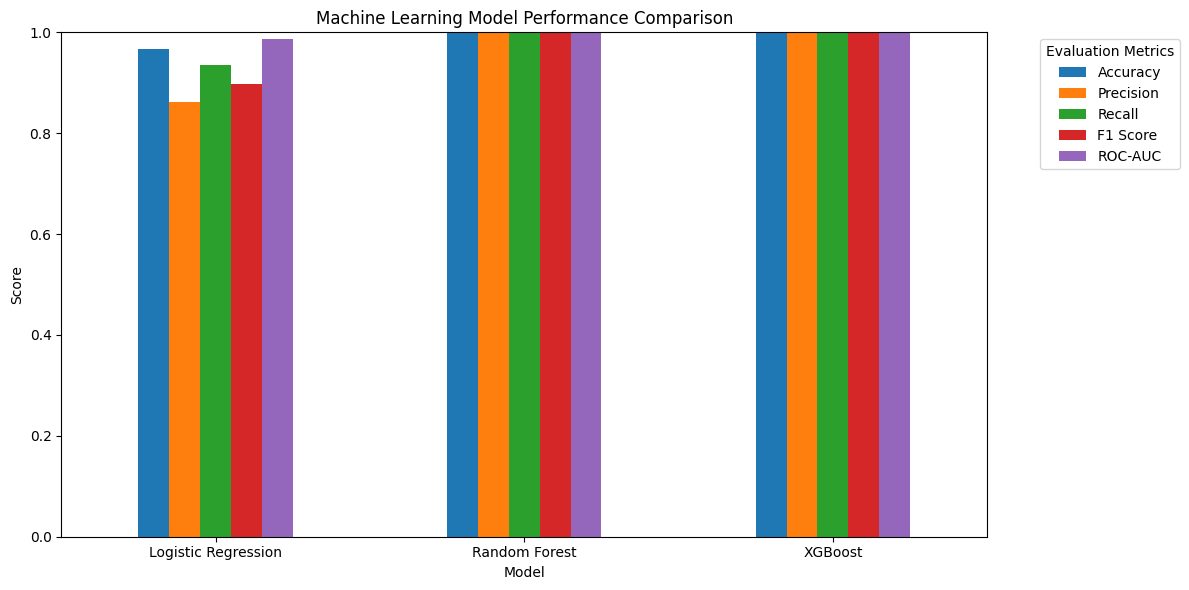

In [179]:
comparison_plot = final_comparison.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()